In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Aldhair\Desktop\hr-analytics-attrition\data\processed\hr_attrition_processed.csv')

print (f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 1470, Columnas: 45


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,0,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,1,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,0,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,1,40,3,1,...,False,True,False,False,False,False,False,False,True,False


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Age                                1470 non-null   int64
 1   Attrition                          1470 non-null   int64
 2   DailyRate                          1470 non-null   int64
 3   DistanceFromHome                   1470 non-null   int64
 4   Education                          1470 non-null   int64
 5   EnvironmentSatisfaction            1470 non-null   int64
 6   Gender                             1470 non-null   int64
 7   HourlyRate                         1470 non-null   int64
 8   JobInvolvement                     1470 non-null   int64
 9   JobLevel                           1470 non-null   int64
 10  JobSatisfaction                    1470 non-null   int64
 11  MonthlyIncome                      1470 non-null   int64
 12  MonthlyRate                    

In [9]:
#Separar features X e target Y
# X = todas las varibales predictoras (excepto Attrition)
# Y = lo que queremos predcir (Attrition)

X = df.drop(columns=['Attrition'])
y = df['Attrition']

print(f"X (features): {X.shape}")
print(f"y (target): {Y.shape}")
print(f"\nDistribución de Y:\n{Y.value_counts()}")

X (features): (1470, 44)
y (target): (1470,)

Distribución de Y:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test: {X_test.shape[0]} filas")
print(f"\nDistribución en train: \n{y_train.value_counts()}")
print(f"\nDistribución en test: \n{y_test.value_counts()}")

Train: 1176 filas
Test: 294 filas

Distribución en train: 
Attrition
0    986
1    190
Name: count, dtype: int64

Distribución en test: 
Attrition
0    247
1     47
Name: count, dtype: int64


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Antes de SMOTE:\n{y_train.value_counts()}")
print(f"\nDespués de SMOTE:\n{y_train_balanced.value_counts()}")

Antes de SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

Después de SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [12]:
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

modelo.fit(X_train_balanced, y_train_balanced)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [13]:
# Predicciones sobre el test set
y_pred = modelo.predict(X_test)

#Métricas
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Recall: {recall:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1-Score: {f1:.2%}")

Accuracy: 82.99%
Recall: 29.79%
Precision: 45.16%
F1-Score: 35.90%


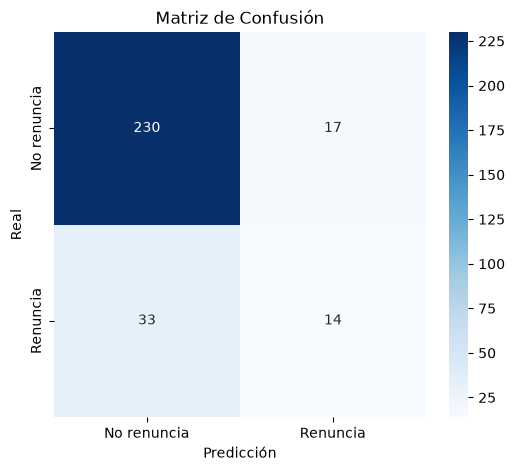

In [14]:
# Se detecta que el recall es bajo, por lo que se consultará en una matriz de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No renuncia', 'Renuncia'],
            yticklabels=['No renuncia', 'Renuncia'])

plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [15]:
# En vez de predict(), usamos predict_proba() para obtener probabilidades
y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidad de "Renuncia"

# Probamos un umbral más bajo (en vez de 0.5)
umbral = 0.35
y_pred_ajustado = (y_proba >= umbral).astype(int)

accuracy = accuracy_score(y_test, y_pred_ajustado)
recall = recall_score(y_test, y_pred_ajustado)
precision = precision_score(y_test, y_pred_ajustado)
f1 = f1_score(y_test, y_pred_ajustado)

print(f"Umbral: {umbral}")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1-Score:  {f1:.2%}")

Umbral: 0.35
Accuracy:  76.87%
Recall:    57.45%
Precision: 36.00%
F1-Score:  44.26%


In [ ]:

y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidad de "Renuncia"

# Bajamos más el umbral para mejorar recall
umbral = 0.25
y_pred_ajustado = (y_proba >= umbral).astype(int)

accuracy = accuracy_score(y_test, y_pred_ajustado)
recall = recall_score(y_test, y_pred_ajustado)
precision = precision_score(y_test, y_pred_ajustado)
f1 = f1_score(y_test, y_pred_ajustado)

print(f"Umbral: {umbral}")
print(f"Accuracy:  {accuracy:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1-Score:  {f1:.2%}")

Umbral: 0.25
Accuracy:  64.63%
Recall:    76.60%
Precision: 27.91%
F1-Score:  40.91%


In [18]:
#Al bajar el umbral, el recall mejor pero se pierde precision
#Ajustamos el modelo en sí

modelo_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

modelo_v2.fit(X_train_balanced, y_train_balanced)

y_proba_v2 = modelo_v2.predict_proba(X_test)[:, 1]

# Probamos varios umbrales de una vez
for umbral in [0.5, 0.45, 0.4, 0.35, 0.3]:
    y_pred_v2 = (y_proba_v2 >= umbral).astype(int)
    acc = accuracy_score(y_test, y_pred_v2)
    rec = recall_score(y_test, y_pred_v2)
    prec = precision_score(y_test, y_pred_v2)
    f1 = f1_score(y_test, y_pred_v2)
    print(f"Umbral {umbral}: Accuracy={acc:.2%}, Recall={rec:.2%}, Precision={prec:.2%}, F1={f1:.2%}")

Umbral 0.5: Accuracy=82.65%, Recall=29.79%, Precision=43.75%, F1=35.44%
Umbral 0.45: Accuracy=81.97%, Recall=38.30%, Precision=42.86%, F1=40.45%
Umbral 0.4: Accuracy=79.93%, Recall=44.68%, Precision=38.89%, F1=41.58%
Umbral 0.35: Accuracy=78.57%, Recall=61.70%, Precision=39.19%, F1=47.93%
Umbral 0.3: Accuracy=73.13%, Recall=68.09%, Precision=33.33%, F1=44.76%


=== MÉTRICAS FINALES ===
Accuracy:  78.57%
Recall:    61.70%
Precision: 39.19%
F1-Score:  47.93%

              precision    recall  f1-score   support

 No renuncia       0.92      0.82      0.87       247
    Renuncia       0.39      0.62      0.48        47

    accuracy                           0.79       294
   macro avg       0.66      0.72      0.67       294
weighted avg       0.83      0.79      0.80       294



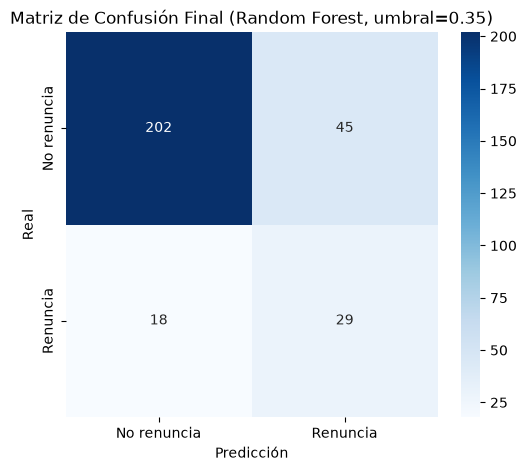

In [21]:
# Usamos modelo_v2 con umbral 0.35 como modelo final
umbral_final = 0.35
y_pred_final = (y_proba_v2 >= umbral_final).astype(int)

print("=== MÉTRICAS FINALES ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_final):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.2%}")
print(f"Precision: {precision_score(y_test, y_pred_final):.2%}")
print(f"F1-Score:  {f1_score(y_test, y_pred_final):.2%}")
print()
print(classification_report(y_test, y_pred_final, target_names=['No renuncia', 'Renuncia']))

# Matriz de confusión final
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No renuncia', 'Renuncia'],
            yticklabels=['No renuncia', 'Renuncia'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Final (Random Forest, umbral=0.35)')
plt.show()